# Temporal PID: Investigating Temporal Structure via Time-Delay Embeddings

This notebook demonstrates how to use the **DIT toolbox** to compute PID on time-delay embeddings of time series, following Pedro Mediano's recommended progression:

1. **Phase 1**: Discrete logic gates with known ground truth (COPY vs XOR)
2. **Phase 2**: Simple AR/VAR processes
3. **Phase 3**: (Later) Natural time series

**Key insight**: By treating lags as "sources" and the next value as "target", PID tells us whether lags carry **redundant**, **unique**, or **synergistic** information.

In [15]:
import numpy as np
import sys
from collections import Counter

# Add dit to path
sys.path.insert(0, r"c:\Users\skite\Documents\Github\temporal-phiid\dit")

import dit
from dit.pid import PID_MMI, PID_BROJA, PID_CCS
from dit import Distribution

# Set display options
dit.ditParams['print.exact'] = dit.ditParams['repr.print'] = True

print("DIT loaded successfully!")

DIT loaded successfully!


## Helper Functions

These functions generate toy time series and build DIT distributions from time-delay embeddings.

In [16]:
def generate_random_binary(n_samples=1000, seed=42):
    """Generate IID random binary sequence."""
    np.random.seed(seed)
    return np.random.randint(0, 2, n_samples)

def generate_copy_process(n_samples=1000, seed=42):
    """
    Generate a process where x_t copies a random source.
    To show REDUNDANCY: x_{t-1} and x_{t-2} carry the same info about x_t
    because x_t = x_{t-1} = x_{t-2} in a perfect copy chain.
    
    We use a slightly noisy copy (5% flip) to avoid degenerate constant sequences.
    """
    np.random.seed(seed)
    x = np.zeros(n_samples, dtype=int)
    x[0] = np.random.randint(2)
    for t in range(1, n_samples):
        # 95% copy, 5% flip - creates non-trivial distribution with high redundancy
        if np.random.rand() < 0.05:
            x[t] = np.random.randint(2)  # Random new value
        else:
            x[t] = x[t-1]  # Copy
    return x

def generate_xor_process(n_samples=1000, seed=42):
    """
    Generate XOR process: x_t = x_{t-1} XOR x_{t-2}
    
    NOTE: This creates a PERIODIC sequence (period 3 typically), so the joint
    distribution won't be uniform. For a clean synergy test, use the
    ideal XOR distribution directly.
    """
    np.random.seed(seed)
    x = np.zeros(n_samples, dtype=int)
    x[0] = np.random.randint(2)
    x[1] = np.random.randint(2)
    for t in range(2, n_samples):
        x[t] = x[t-1] ^ x[t-2]  # XOR
    return x

def generate_noisy_copy_process(n_samples=1000, noise_prob=0.1, seed=42):
    """Generate noisy copy: x_t = x_{t-1} with probability (1-noise_prob)"""
    np.random.seed(seed)
    x = np.zeros(n_samples, dtype=int)
    x[0] = np.random.randint(2)
    for t in range(1, n_samples):
        if np.random.rand() < noise_prob:
            x[t] = 1 - x[t-1]  # Flip
        else:
            x[t] = x[t-1]  # Copy
    return x

def build_embedding_distribution(x, lags=[1, 2]):
    """
    Build a dit Distribution from time series with specified lags.
    
    Sources: x[t - lag] for each lag in `lags`
    Target:  x[t]
    
    Returns a Distribution over (source_1, source_2, ..., target).
    """
    max_lag = max(lags)
    n = len(x)
    
    # Build tuples: (x[t-lag1], x[t-lag2], ..., x[t])
    outcomes = []
    for t in range(max_lag, n):
        outcome = tuple(x[t - lag] for lag in lags) + (x[t],)
        outcomes.append(''.join(map(str, outcome)))
    
    # Count frequencies
    counts = Counter(outcomes)
    total = sum(counts.values())
    
    outcomes_list = list(counts.keys())
    probs = [counts[o] / total for o in outcomes_list]
    
    return Distribution(outcomes_list, probs)

print("Helper functions defined!")

Helper functions defined!


---
# Phase 1: Discrete Logic Gates with Known Ground Truth

We start with systems where we **know the answer ahead of time**:

| System | Expected PID result |
|--------|---------------------|
| **COPY**: $x_t = x_{t-1}$ | Lag-1 has all unique info; lag-2 is redundant |
| **XOR**: $x_t = x_{t-1} \oplus x_{t-2}$ | Neither lag alone predicts → pure synergy |

## 1.1 COPY Process (with small noise to avoid degeneracy)

**Expected**: Both lags should carry similar info → high **redundancy**.

Since a perfect COPY creates a constant sequence (no information), we use a 95% copy / 5% random flip. This creates a non-trivial distribution where $x_{t-1}$ and $x_{t-2}$ carry highly overlapping (redundant) information about $x_t$.

In [17]:
# Generate COPY process
x_copy = generate_copy_process(n_samples=10000)
dist_copy = build_embedding_distribution(x_copy, lags=[1, 2])

print("Distribution (lag-1, lag-2, target):")
print(dist_copy)

Distribution (lag-1, lag-2, target):
Class:          Distribution
Alphabet:       ('0', '1') for all rvs
Base:           linear
Outcome Class:  str
Outcome Length: 3
RV Names:       None

x     p(x)
000   5051/9998
001   65/4999
010   129/9998
011   2/4999
100   1/9998
101   133/9998
110   66/4999
111   2209/4999


In [18]:
# Compute PID using MMI (Minimum Mutual Information)
pid_copy = PID_MMI(dist_copy)
print("PID for COPY process:")
print(pid_copy)

PID for COPY process:
+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 0.8199 | 0.0000 |
|  {0}   | 0.8196 | 0.1189 |
|  {1}   | 0.7007 | 0.0000 |
| {0}{1} | 0.7007 | 0.7007 |
+--------+--------+--------+


**Interpretation**: You should see substantial **redundancy** — both lags carry overlapping information about the target.

Let's also test the **ideal redundancy distribution** from DIT:

In [19]:
# Load the IDEAL distributions from DIT's built-in examples
from dit.pid.distributions import bivariates

ideal_rdn = bivariates['redundant']  # X1 = X2 = Y (perfect redundancy)
print("Ideal REDUNDANCY distribution (X1 = X2 = Y):")
print(ideal_rdn)

print("\nPID for IDEAL redundancy (ground truth - should show PURE REDUNDANCY):")
print(PID_MMI(ideal_rdn))

Ideal REDUNDANCY distribution (X1 = X2 = Y):
Class:          Distribution
Alphabet:       ('0', '1') for all rvs
Base:           linear
Outcome Class:  str
Outcome Length: 3
RV Names:       None

x     p(x)
000   1/2
111   1/2

PID for IDEAL redundancy (ground truth - should show PURE REDUNDANCY):
+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 1.0000 | 0.0000 |
|  {0}   | 1.0000 | 0.0000 |
|  {1}   | 1.0000 | 0.0000 |
| {0}{1} | 1.0000 | 1.0000 |
+--------+--------+--------+


## 1.2 XOR Process: $x_t = x_{t-1} \oplus x_{t-2}$

**Expected**: Neither lag alone predicts → **pure synergy**. You need BOTH lags together.

In [20]:
# Generate XOR process
x_xor = generate_xor_process(n_samples=10000)
dist_xor = build_embedding_distribution(x_xor, lags=[1, 2])

print("Distribution (lag-1, lag-2, target):")
print(dist_xor)

Distribution (lag-1, lag-2, target):
Class:          Distribution
Alphabet:       ('0', '1') for all rvs
Base:           linear
Outcome Class:  str
Outcome Length: 3
RV Names:       None

x     p(x)
011   1666/4999
101   3333/9998
110   3333/9998


In [21]:
# Compute PID
pid_xor = PID_MMI(dist_xor)
print("PID for XOR process:")
print(pid_xor)

PID for XOR process:
+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 0.9183 | 0.6666 |
|  {0}   | 0.2516 | 0.0000 |
|  {1}   | 0.2517 | 0.0000 |
| {0}{1} | 0.2516 | 0.2516 |
+--------+--------+--------+


**Issue**: The XOR time series creates a *periodic* sequence (not uniform), so the PID won't show pure synergy.

Let's also test the **ideal XOR distribution** from DIT's built-in examples:

In [22]:
# Load the IDEAL XOR/synergy distribution from DIT's built-in examples
ideal_xor = bivariates['synergy']  # Y = X1 XOR X2 (pure synergy)
print("Ideal XOR/SYNERGY distribution:")
print(ideal_xor)

print("\nPID for IDEAL XOR (ground truth - should show PURE SYNERGY):")
print(PID_MMI(ideal_xor))

Ideal XOR/SYNERGY distribution:
Class:          Distribution
Alphabet:       ('0', '1') for all rvs
Base:           linear
Outcome Class:  str
Outcome Length: 3
RV Names:       None

x     p(x)
000   1/4
011   1/4
101   1/4
110   1/4

PID for IDEAL XOR (ground truth - should show PURE SYNERGY):


+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 1.0000 | 1.0000 |
|  {0}   | 0.0000 | 0.0000 |
|  {1}   | 0.0000 | 0.0000 |
| {0}{1} | 0.0000 | 0.0000 |
+--------+--------+--------+


## 1.3 Noisy COPY Process

**Expected**: Mostly unique info in lag-1, some redundancy with lag-2, but imperfect.

In [23]:
# Generate noisy COPY
x_noisy = generate_noisy_copy_process(n_samples=10000, noise_prob=0.1)
dist_noisy = build_embedding_distribution(x_noisy, lags=[1, 2])

pid_noisy = PID_MMI(dist_noisy)
print("PID for Noisy COPY (10% noise):")
print(pid_noisy)

PID for Noisy COPY (10% noise):
+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 0.5259 | 0.0000 |
|  {0}   | 0.5255 | 0.2042 |
|  {1}   | 0.3212 | 0.0000 |
| {0}{1} | 0.3212 | 0.3212 |
+--------+--------+--------+


---
# Phase 2: Autoregressive Processes

Now we move to continuous processes that we discretize. AR processes let us control **which lag matters**.

In [24]:
def generate_ar2_process(n_samples=1000, a1=0.3, a2=0.5, noise_std=0.5, seed=42):
    """
    Generate AR(2) process: x_t = a1*x_{t-1} + a2*x_{t-2} + noise
    
    If a2 > a1, lag-2 should carry more unique info.
    """
    np.random.seed(seed)
    x = np.zeros(n_samples)
    x[0] = np.random.randn()
    x[1] = np.random.randn()
    for t in range(2, n_samples):
        x[t] = a1 * x[t-1] + a2 * x[t-2] + noise_std * np.random.randn()
    return x

def discretize_timeseries(x, n_bins=4, method='quantile'):
    """
    Discretize continuous time series into symbols.
    
    Methods:
    - 'quantile': Equal-frequency binning
    - 'uniform': Equal-width binning
    """
    if method == 'quantile':
        percentiles = np.linspace(0, 100, n_bins + 1)
        bins = np.percentile(x, percentiles)
        bins[0] -= 1e-10
        bins[-1] += 1e-10
    else:
        bins = np.linspace(x.min() - 1e-10, x.max() + 1e-10, n_bins + 1)
    
    return np.digitize(x, bins[1:-1])

print("AR functions defined!")

AR functions defined!


## 2.1 AR(2) where lag-2 dominates ($a_1=0.3$, $a_2=0.5$)

**Expected**: Lag-2 should show more unique information than lag-1.

In [25]:
# AR(2) with a2 > a1
x_ar2 = generate_ar2_process(n_samples=10000, a1=0.3, a2=0.5)
x_ar2_discrete = discretize_timeseries(x_ar2, n_bins=4)

dist_ar2 = build_embedding_distribution(x_ar2_discrete, lags=[1, 2])

pid_ar2 = PID_MMI(dist_ar2)
print("PID for AR(2) with a1=0.3, a2=0.5 (lag-2 dominates):")
print(pid_ar2)

PID for AR(2) with a1=0.3, a2=0.5 (lag-2 dominates):
+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 0.3657 | 0.0682 |
|  {0}   | 0.2084 | 0.0000 |
|  {1}   | 0.2975 | 0.0891 |
| {0}{1} | 0.2084 | 0.2084 |
+--------+--------+--------+


## 2.2 AR(2) where lag-1 dominates ($a_1=0.7$, $a_2=0.1$)

**Expected**: Lag-1 should show more unique information.

In [26]:
# AR(2) with a1 > a2
x_ar2_b = generate_ar2_process(n_samples=10000, a1=0.7, a2=0.1)
x_ar2_b_discrete = discretize_timeseries(x_ar2_b, n_bins=4)

dist_ar2_b = build_embedding_distribution(x_ar2_b_discrete, lags=[1, 2])

pid_ar2_b = PID_MMI(dist_ar2_b)
print("PID for AR(2) with a1=0.7, a2=0.1 (lag-1 dominates):")
print(pid_ar2_b)

PID for AR(2) with a1=0.7, a2=0.1 (lag-1 dominates):
+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 0.4566 | 0.0228 |
|  {0}   | 0.4338 | 0.1791 |
|  {1}   | 0.2547 | 0.0000 |
| {0}{1} | 0.2547 | 0.2547 |
+--------+--------+--------+


---
# Comparing PID Measures

Different PID definitions can give different results. The main ones in DIT are:
- **PID_MMI**: Minimum Mutual Information (fast, can have issues)
- **PID_BROJA**: BROJA measure (optimization-based)
- **PID_CCS**: Common Change in Surprisal

In [27]:
print("XOR distribution - comparing PID measures:")
print("\n--- PID_MMI (Minimum Mutual Information) ---")
print(PID_MMI(dist_xor))

print("\n--- PID_BROJA ---")
print(PID_BROJA(dist_xor))

print("\n--- PID_CCS (Common Change in Surprisal) ---")
print(PID_CCS(dist_xor))

XOR distribution - comparing PID measures:

--- PID_MMI (Minimum Mutual Information) ---
+--------+--------+--------+
| I_mmi  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 0.9183 | 0.6666 |
|  {0}   | 0.2516 | 0.0000 |
|  {1}   | 0.2517 | 0.0000 |
| {0}{1} | 0.2516 | 0.2516 |
+--------+--------+--------+

--- PID_BROJA ---
+---------+--------+--------+
| I_broja |  I_r   |   pi   |
+---------+--------+--------+
|  {0:1}  | 0.9183 | 0.6666 |
|   {0}   | 0.2516 | 0.0000 |
|   {1}   | 0.2517 | 0.0000 |
|  {0}{1} | 0.2516 | 0.2516 |
+---------+--------+--------+

--- PID_CCS (Common Change in Surprisal) ---
+--------+--------+--------+
| I_ccs  |  I_r   |   pi   |
+--------+--------+--------+
| {0:1}  | 0.9183 | 0.4150 |
|  {0}   | 0.2516 | 0.2516 |
|  {1}   | 0.2517 | 0.2517 |
| {0}{1} | 0.0000 | 0.0000 |
+--------+--------+--------+


---
# Sweep: How PID Changes Across Lag Pairs

This is the core of your project: mapping how **redundancy/uniqueness/synergy varies with lag structure**.

In [ ]:
def compute_pid_summary(dist, pid_class=PID_MMI):
    """Extract key PID values from a distribution."""
    pid = pid_class(dist)
    
    # The PID lattice nodes are tuples of tuples. For bivariate PID:
    # The nodes represent which sources are "included" at each level
    # We need to iterate and identify by structure
    
    summary = {'redundancy': 0.0, 'unique_0': 0.0, 'unique_1': 0.0, 'synergy': 0.0}
    
    # Use get_pi() method which works with both local and pip-installed dit
    for node in pid._lattice:
        try:
            val = float(pid.get_pi(node))
        except:
            val = 0.0
        
        # Identify node type by its structure
        # Redundancy: both sources at finest grain - ((0,), (1,))
        if len(node) == 2 and all(len(n) == 1 for n in node):
            summary['redundancy'] = val
        # Synergy: both sources together - ((0, 1),)
        elif len(node) == 1 and len(node[0]) == 2:
            summary['synergy'] = val
        # Unique to source 0: only source 0 - ((0,),)
        elif node == ((0,),):
            summary['unique_0'] = val
        # Unique to source 1: only source 1 - ((1,),)
        elif node == ((1,),):
            summary['unique_1'] = val
    
    return summary

# Test it
print("Testing compute_pid_summary on ideal XOR:")
test_summary = compute_pid_summary(ideal_xor)
print(f"  Redundancy: {test_summary['redundancy']:.4f}")
print(f"  Unique_0:   {test_summary['unique_0']:.4f}")
print(f"  Unique_1:   {test_summary['unique_1']:.4f}")
print(f"  Synergy:    {test_summary['synergy']:.4f}")

Testing compute_pid_summary on ideal XOR:
  Redundancy: 0.0000
  Unique_0:   0.0000
  Unique_1:   0.0000
  Synergy:    1.0000


In [29]:
def generate_mixed_timescale(n_samples=10000, seed=42):
    """
    Generate a process with multiple timescales:
    x_t = 0.4*x_{t-1} + 0.3*x_{t-3} + noise
    
    This should show interesting structure when we look at different lag pairs.
    """
    np.random.seed(seed)
    x = np.zeros(n_samples)
    for i in range(4):
        x[i] = np.random.randn()
    for t in range(4, n_samples):
        x[t] = 0.4 * x[t-1] + 0.3 * x[t-3] + 0.4 * np.random.randn()
    return x

# Generate mixed-timescale process
x_mixed = generate_mixed_timescale()
x_mixed_discrete = discretize_timeseries(x_mixed, n_bins=4)

# Sweep over lag pairs
lag_pairs = [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

print("Mixed-timescale AR: x_t = 0.4*x_{t-1} + 0.3*x_{t-3} + noise")
print("\nLag pair | Redundancy | Unique(lag1) | Unique(lag2) | Synergy")
print("-" * 65)

for lag1, lag2 in lag_pairs:
    dist = build_embedding_distribution(x_mixed_discrete, lags=[lag1, lag2])
    summary = compute_pid_summary(dist)
    print(f"({lag1}, {lag2})    |   {summary.get('redundancy', 0):.4f}   |"
          f"    {summary.get('unique_0', 0):.4f}    |"
          f"    {summary.get('unique_1', 0):.4f}    |  {summary.get('synergy', 0):.4f}")

Mixed-timescale AR: x_t = 0.4*x_{t-1} + 0.3*x_{t-3} + noise

Lag pair | Redundancy | Unique(lag1) | Unique(lag2) | Synergy
-----------------------------------------------------------------
(1, 2)    |   0.0597   |    0.0766    |    0.0000    |  0.0148
(1, 3)    |   0.1003   |    0.0361    |    0.0000    |  0.0614
(1, 4)    |   0.0509   |    0.0854    |    0.0000    |  0.0154
(2, 3)    |   0.0597   |    0.0000    |    0.0406    |  0.0200
(2, 4)    |   0.0509   |    0.0088    |    0.0000    |  0.0308
(3, 4)    |   0.0509   |    0.0493    |    0.0000    |  0.0148


---
# Next Steps

## Immediate validation (do this first!):
1. ✅ Logic gates (COPY, XOR) — done above
2. ✅ AR processes — done above
3. 🔲 Coupled oscillators (Kuramoto, neural masses)
4. 🔲 Delayed COPY/XOR at specific lags

## Discretization experiments:
- Compare ordinal patterns vs binning
- Test sensitivity to number of bins
- Consider symbolic dynamics (permutation entropy style)

## Move to PhiID:
- Use the `phyid` package for past→future decomposition
- See `02_temporal_phiid_starter.py` for examples

## Natural time series:
- Start with short embeddings (2-4 lags)
- Compare "temporal fingerprints" across signal types
- Look for synergy vs redundancy signatures

In [30]:
# =============================================================================
# SCENARIO: Redundancy and Synergy at DIFFERENT lag pairs
# =============================================================================

def generate_hierarchical_timescales(n_samples=20000, seed=42):
    """
    Generate a process with SEPARATED redundancy and synergy:
    
    - MEMORY at short timescales: x_t depends on x_{t-1} (creates redundancy at lags 1,2,3)
    - XOR at longer timescales: x_t also depends on x_{t-5} XOR x_{t-6} (creates synergy at 5,6)
    
    This should produce:
    - Redundancy peak at (1,2) or (1,3)
    - Synergy peak at (5,6)
    """
    np.random.seed(seed)
    x = np.zeros(n_samples, dtype=int)
    
    # Initialize
    for i in range(7):
        x[i] = np.random.randint(2)
    
    for t in range(7, n_samples):
        # 60% of the time: copy from lag-1 (creates redundancy in short lags)
        # 30% of the time: XOR of lag-5 and lag-6 (creates synergy in long lags)  
        # 10% of the time: random (noise)
        r = np.random.rand()
        if r < 0.6:
            x[t] = x[t-1]  # COPY → redundancy at nearby lags
        elif r < 0.9:
            x[t] = x[t-5] ^ x[t-6]  # XOR → synergy at lags 5,6
        else:
            x[t] = np.random.randint(2)  # noise
    
    return x

# Generate the hierarchical process
x_hier = generate_hierarchical_timescales()

# Compute PID for all lag pairs up to 7
max_lag = 7
results_hier = []

print("HIERARCHICAL TIMESCALES: Memory (lags 1-2) + XOR (lags 5-6)")
print("=" * 70)
print("\nLag pair | Redundancy | Unique(lag1) | Unique(lag2) | Synergy")
print("-" * 65)

for lag1 in range(1, max_lag):
    for lag2 in range(lag1 + 1, max_lag + 1):
        dist = build_embedding_distribution(x_hier, lags=[lag1, lag2])
        summary = compute_pid_summary(dist)
        summary['lag1'] = lag1
        summary['lag2'] = lag2
        results_hier.append(summary)
        print(f"({lag1}, {lag2})    |   {summary['redundancy']:.4f}   |"
              f"    {summary['unique_0']:.4f}    |"
              f"    {summary['unique_1']:.4f}    |  {summary['synergy']:.4f}")

# Find peaks
import pandas as pd
df_hier = pd.DataFrame(results_hier)
red_peak = df_hier.loc[df_hier['redundancy'].idxmax()]
syn_peak = df_hier.loc[df_hier['synergy'].idxmax()]

print("\n" + "=" * 70)
print(f"REDUNDANCY PEAK: lags ({int(red_peak['lag1'])}, {int(red_peak['lag2'])}) = {red_peak['redundancy']:.4f}")
print(f"SYNERGY PEAK:    lags ({int(syn_peak['lag1'])}, {int(syn_peak['lag2'])}) = {syn_peak['synergy']:.4f}")
print("=" * 70)

if (red_peak['lag1'], red_peak['lag2']) != (syn_peak['lag1'], syn_peak['lag2']):
    print("\n✓ SUCCESS: Redundancy and Synergy peak at DIFFERENT lag pairs!")
    print("  → This indicates HIERARCHICAL temporal structure:")
    print(f"     - Memory/persistence at lags {int(red_peak['lag1'])}-{int(red_peak['lag2'])}")
    print(f"     - Nonlinear interaction at lags {int(syn_peak['lag1'])}-{int(syn_peak['lag2'])}")

HIERARCHICAL TIMESCALES: Memory (lags 1-2) + XOR (lags 5-6)

Lag pair | Redundancy | Unique(lag1) | Unique(lag2) | Synergy
-----------------------------------------------------------------
(1, 2)    |   0.0929   |    0.1464    |    0.0000    |  0.0006
(1, 3)    |   0.0387   |    0.2006    |    0.0000    |  0.0007
(1, 4)    |   0.0199   |    0.2194    |    0.0000    |  0.0016
(1, 5)    |   0.0150   |    0.2243    |    0.0000    |  0.0041
(1, 6)    |   0.0132   |    0.2262    |    0.0000    |  0.0066
(1, 7)    |   0.0090   |    0.2304    |    0.0000    |  0.0033
(2, 3)    |   0.0387   |    0.0542    |    0.0000    |  0.0005
(2, 4)    |   0.0199   |    0.0730    |    0.0000    |  0.0014
(2, 5)    |   0.0150   |    0.0778    |    0.0000    |  0.0039
(2, 6)    |   0.0132   |    0.0797    |    0.0000    |  0.0100
(2, 7)    |   0.0090   |    0.0839    |    0.0000    |  0.0072
(3, 4)    |   0.0199   |    0.0188    |    0.0000    |  0.0009
(3, 5)    |   0.0150   |    0.0237    |    0.0000    | 

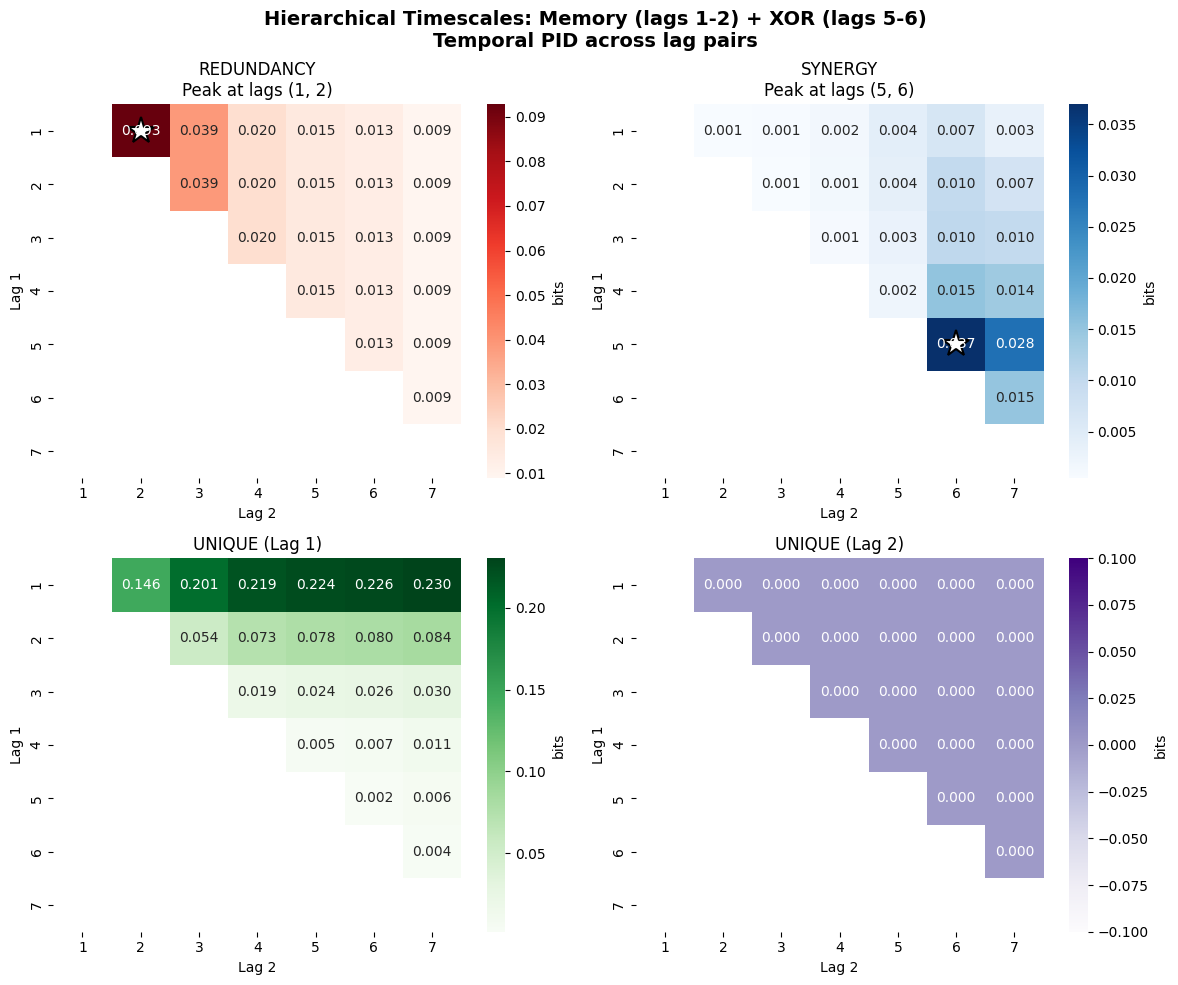


✓ Heatmaps show SEPARATED temporal structure:
  → REDUNDANCY (memory) peaks at short lags (1, 2)
  → SYNERGY (XOR interaction) peaks at longer lags (5, 6)


In [31]:
# =============================================================================
# HEATMAP VISUALIZATION: Hierarchical Timescales
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Create matrices for heatmap (lag1 x lag2)
lags = list(range(1, max_lag + 1))
n_lags = len(lags)

# Initialize matrices with NaN (since we only have upper triangle)
red_matrix = np.full((n_lags, n_lags), np.nan)
syn_matrix = np.full((n_lags, n_lags), np.nan)
uniq0_matrix = np.full((n_lags, n_lags), np.nan)
uniq1_matrix = np.full((n_lags, n_lags), np.nan)

# Fill matrices from results
for result in results_hier:
    i = result['lag1'] - 1  # 0-indexed
    j = result['lag2'] - 1
    red_matrix[i, j] = result['redundancy']
    syn_matrix[i, j] = result['synergy']
    uniq0_matrix[i, j] = result['unique_0']
    uniq1_matrix[i, j] = result['unique_1']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Helper function for heatmap with annotation
def plot_heatmap(ax, matrix, title, cmap, peak_val=None, peak_coords=None):
    mask = np.isnan(matrix)
    sns.heatmap(matrix, ax=ax, annot=True, fmt='.3f', cmap=cmap, 
                mask=mask, xticklabels=lags, yticklabels=lags,
                cbar_kws={'label': 'bits'})
    ax.set_xlabel('Lag 2')
    ax.set_ylabel('Lag 1')
    ax.set_title(title)
    
    # Mark peak with a star
    if peak_coords is not None:
        ax.plot(peak_coords[1] - 0.5, peak_coords[0] - 0.5, 'w*', markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5)

# Plot each component
plot_heatmap(axes[0, 0], red_matrix, 
             f'REDUNDANCY\nPeak at lags ({int(red_peak["lag1"])}, {int(red_peak["lag2"])})', 
             'Reds', peak_coords=(int(red_peak['lag1']), int(red_peak['lag2'])))

plot_heatmap(axes[0, 1], syn_matrix, 
             f'SYNERGY\nPeak at lags ({int(syn_peak["lag1"])}, {int(syn_peak["lag2"])})', 
             'Blues', peak_coords=(int(syn_peak['lag1']), int(syn_peak['lag2'])))

plot_heatmap(axes[1, 0], uniq0_matrix, 'UNIQUE (Lag 1)', 'Greens')
plot_heatmap(axes[1, 1], uniq1_matrix, 'UNIQUE (Lag 2)', 'Purples')

plt.suptitle('Hierarchical Timescales: Memory (lags 1-2) + XOR (lags 5-6)\n'
             'Temporal PID across lag pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Heatmaps show SEPARATED temporal structure:")
print(f"  → REDUNDANCY (memory) peaks at short lags ({int(red_peak['lag1'])}, {int(red_peak['lag2'])})")
print(f"  → SYNERGY (XOR interaction) peaks at longer lags ({int(syn_peak['lag1'])}, {int(syn_peak['lag2'])})")